In [0]:
storage_account_name = "datalake60306249"
storage_account_key = "7G2tmMYVeA+Zamq6y+efmYamIo1OeBnKxzRUeVMqN91qn7bANbEEq0szMvcTHBFgIayEs7X0RgNo+ASt1ApzIg=="
spark.conf.set(
f"fs.azure.account.key.{storage_account_name}.dfs.core.windows.net",
storage_account_key
)

In [0]:
gold_path = "abfss://curated@datalake60306249.dfs.core.windows.net/features_v1/"
gold_df = spark.read.parquet(gold_path)

In [0]:
print(f"Total reviews: {gold_df.count()}")
gold_df.printSchema()
display(gold_df.limit(5))

Total reviews: 28686259
root
 |-- asin: string (nullable = true)
 |-- title: string (nullable = true)
 |-- brand: string (nullable = true)
 |-- price: double (nullable = true)
 |-- reviewerID: string (nullable = true)
 |-- overall: double (nullable = true)
 |-- summary: string (nullable = true)
 |-- reviewText: string (nullable = true)
 |-- helpful: array (nullable = true)
 |    |-- element: integer (containsNull = true)
 |-- reviewTime: string (nullable = true)
 |-- review_year: integer (nullable = true)



asin,title,brand,price,reviewerID,overall,summary,reviewText,helpful,reviewTime,review_year
B008O0ZRNS,"iXCC Quality iPad To HDMI Cable Adapter For Apple iPad, iPad 2, the New iPad 3, iPhone 4, iPhone 4S And iTouch 4",null,18.99,A3EB7PIM7O6JXA,5.0,Works great,"I cannot compare it to the name brand because I do not have the name brand. But, with an HDMI cable and an HD tv with a HD signal, I can tell no difference between the signal from the ipad and my HD DVR.","List(0, 0)","01 11, 2013",2013
B008O0ZRNS,"iXCC Quality iPad To HDMI Cable Adapter For Apple iPad, iPad 2, the New iPad 3, iPhone 4, iPhone 4S And iTouch 4",null,18.99,A8GQ7G2HRJMES,2.0,It worked ofr a little while,"It is no longer available because it is not very durable and the neck tore and it was rendered useless. This occurred during routine use. Hey, make a durable product. Geez!! There are others out there, shop there.","List(0, 0)","02 8, 2013",2013
B008O0ZRNS,"iXCC Quality iPad To HDMI Cable Adapter For Apple iPad, iPad 2, the New iPad 3, iPhone 4, iPhone 4S And iTouch 4",null,18.99,ATDM0XN2MJG2U,5.0,Ipad to HDMI cable,The product arrived on time. It is a very handy piece to have for us who travel for presentations. Small enough to lug around.,"List(0, 0)","02 20, 2013",2013
B008O0ZRNS,"iXCC Quality iPad To HDMI Cable Adapter For Apple iPad, iPad 2, the New iPad 3, iPhone 4, iPhone 4S And iTouch 4",null,18.99,A263O1568N5W0S,5.0,Watch Netflix 1080p,Hooked to my Ipad4 to my new Vizo Smart Tv and watched the best picture I've ever seen o tv. Bozo is just a mid range led but with the retina display hooked directly to my HDMI it couldn't be any better. Use the tv without the retina display IPad and the difference is clear,"List(0, 0)","01 12, 2013",2013
B008O0ZRNS,"iXCC Quality iPad To HDMI Cable Adapter For Apple iPad, iPad 2, the New iPad 3, iPhone 4, iPhone 4S And iTouch 4",null,18.99,A310LDM40EGGHN,4.0,Product worked well.,"This product worked so well, that after loaning to a friend, it has not been returned. It does not charge your device though.","List(0, 0)","12 17, 2013",2013


In [0]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

gold_pd = gold_df.sample(fraction=0.05, seed=42).toPandas() #5% 
print(f"Sample size: {len(gold_pd)} reviews")

Sample size: 1435396 reviews


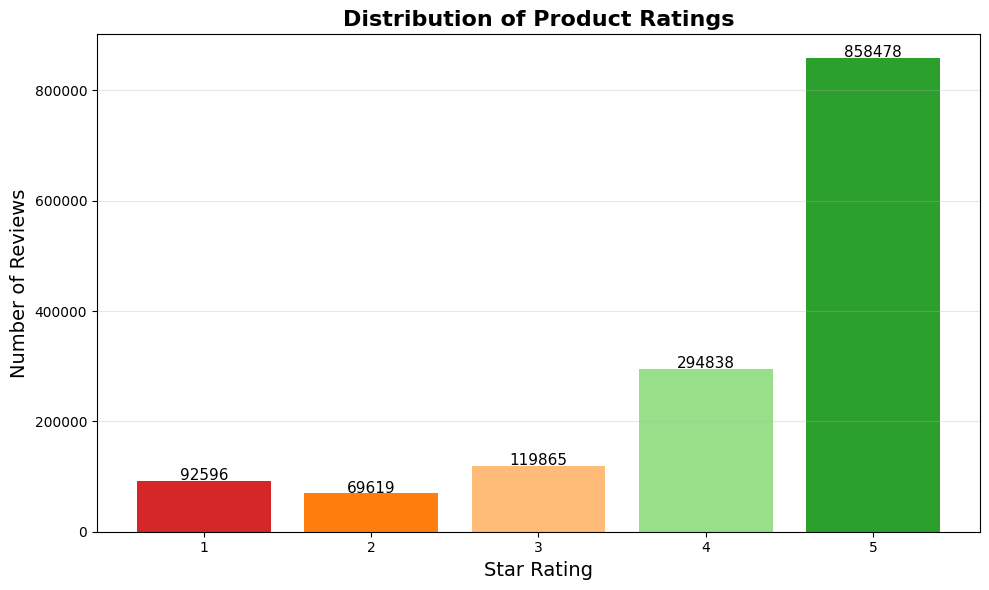


Rating Percentages:
1.0 stars: 6.5%
2.0 stars: 4.9%
3.0 stars: 8.4%
4.0 stars: 20.5%
5.0 stars: 59.8%


In [0]:
#Rating distribution
plt.figure(figsize=(10, 6))
rating_counts = gold_pd['overall'].value_counts().sort_index()

plt.bar(rating_counts.index, rating_counts.values, color=['#d62728', '#ff7f0e', '#ffbb78', '#98df8a', '#2ca02c'])
plt.xlabel('Star Rating', fontsize=14)
plt.ylabel('Number of Reviews', fontsize=14)
plt.title('Distribution of Product Ratings', fontsize=16, fontweight='bold')
plt.xticks([1, 2, 3, 4, 5])

for i, v in enumerate(rating_counts.values):
    plt.text(rating_counts.index[i], v + 1000, str(v), ha='center', fontsize=11)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nRating Percentages:")
for rating in sorted(rating_counts.index):
    pct = (rating_counts[rating] / len(gold_pd)) * 100
    print(f"{rating} stars: {pct:.1f}%")

/home/spark-144bd57c-f36f-4f80-9080-68/.ipykernel/2244/command-8041605690917703-2173083190:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([gold_pd[gold_pd['overall'] == i]['review_length'] for i in range(1, 6)],


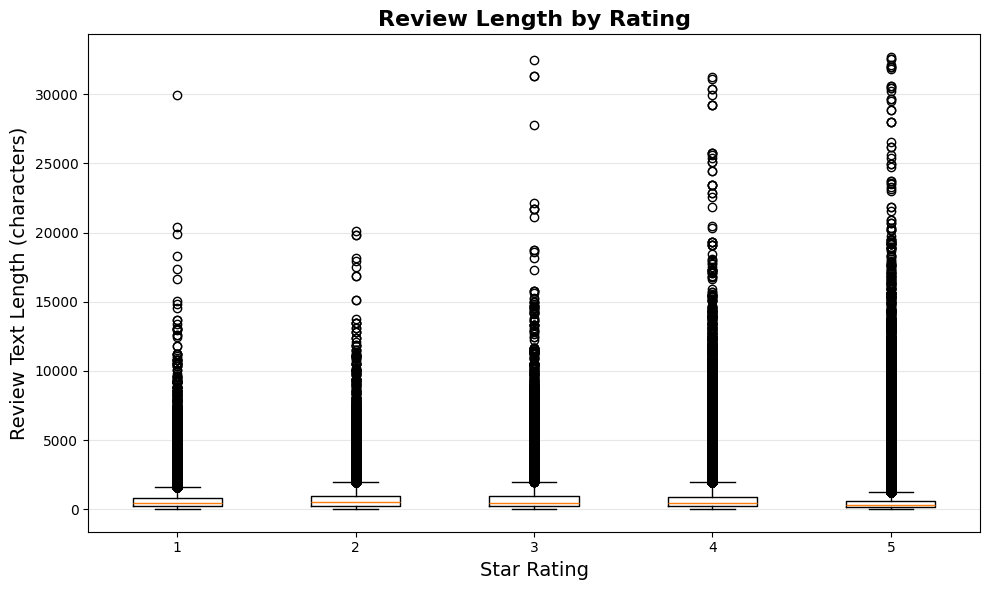

In [0]:
#Review Text Length vs Rating
gold_pd['review_length'] = gold_pd['reviewText'].fillna('').str.len()

plt.figure(figsize=(10, 6))
plt.boxplot([gold_pd[gold_pd['overall'] == i]['review_length'] for i in range(1, 6)],
            labels=['1', '2', '3', '4', '5'])
plt.xlabel('Star Rating', fontsize=14)
plt.ylabel('Review Text Length (characters)', fontsize=14)
plt.title('Review Length by Rating', fontsize=16, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()